In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_style("whitegrid")

# Display settings
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("/content/fraudTrain.csv")

In [3]:
df.sample(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
18406,18406,2019-01-12 03:17:46,6523180720198790,"fraud_Swaniawski, Lowe and Robel",shopping_pos,9.06,Alan,Taylor,M,560 Molina Path,Oakdale,NY,11769,40.7382,-73.1297,9506,"Biochemist, clinical",1953-04-13,842594f97c5cf1907bbc78ff69b77019,1326338266,41.011456,-73.609939,0.0
4910,4910,2019-01-04 03:21:26,370612217861404,"fraud_Towne, Walker and Borer",grocery_net,83.22,Amanda,Fitzgerald,F,298 Kayla Lights,Bristol,PA,19007,40.1159,-74.8536,21125,"Administrator, charities/voluntary organisations",1985-05-25,ba60061d65969c08dcb3208f4a169948,1325647286,40.194735,-75.393341,0.0
13425,13425,2019-01-08 15:37:20,4005676619255478,fraud_Padberg-Sauer,home,97.06,William,Perry,M,458 Phillips Island Apt. 768,Denham Springs,LA,70726,30.4590,-90.9027,71335,Herbalist,1994-05-31,f44a3c1ba89ff4f5d36a00f63ba0e841,1326037040,30.606484,-91.532862,0.0
14003,14003,2019-01-08 20:33:51,213136802746375,fraud_Reichert-Weissnat,travel,7.99,Christine,Davis,F,736 Moss Motorway Suite 549,Humboldt,AZ,86329,34.5189,-112.2523,1179,"Civil engineer, contracting",1955-01-20,76f4801d91a544679a19f47ac891a122,1326054831,33.528060,-111.732944,0.0
28527,28527,2019-01-17 17:36:46,3553629419254918,fraud_Bode-Schuster,kids_pets,233.56,Sharon,Johnson,F,7202 Jeffrey Mills,Conway,WA,98238,48.3400,-122.3456,85,"Research officer, political party",1984-09-01,d90b9c6d7c7105a6bc52c0f3cb4d17a4,1326821806,49.016592,-122.358861,0.0
9023,9023,2019-01-06 17:38:28,6011348830550197,"fraud_Towne, Greenholt and Koepp",shopping_net,855.38,Samuel,Johnston,M,16285 Jessica Lights,Birmingham,AL,35229,33.4629,-86.7904,493806,Musician,1980-07-12,1f7a46194138570c8127edef3964c1c0,1325871508,34.306496,-87.636875,0.0
5773,5773,2019-01-04 18:02:53,6592243974328236,fraud_Langworth LLC,personal_care,1.06,Philip,Hart,M,97405 Vazquez Plains,Montgomery,AL,36111,32.3374,-86.2715,214703,"Chemist, analytical",1994-10-07,59fdac183d4f170e6d69eced663d04e5,1325700173,32.157990,-86.774017,0.0
14892,14892,2019-01-09 12:19:50,3564839259330465,fraud_Kihn-Fritsch,food_dining,18.99,Robert,Ashley,M,1250 Christopher Prairie Suite 016,Port Costa,CA,94569,38.0460,-122.1866,198,Armed forces training and education officer,1959-03-31,5159e80be11de0760169bab6d56a9e4c,1326111590,37.762102,-122.257838,0.0
27787,27787,2019-01-17 02:27:02,6534628260579800,fraud_Emard Inc,gas_transport,66.37,Christine,Harris,F,29606 Martinez Views Suite 653,Hinesburg,VT,5461,44.3346,-73.0980,4542,Claims inspector/assessor,1998-03-19,a6c80871ca4ea752e9717b456d883bd8,1326767222,43.594342,-73.290043,0.0
19769,19769,2019-01-13 00:36:27,38057513087029,"fraud_Raynor, Reinger and Hagenes",gas_transport,61.97,Marissa,Clark,F,2677 Byrd Village Suite 035,San Jose,CA,95148,37.3304,-121.7913,973849,Geoscientist,1997-01-18,6024db06af5a79c23d04cbec32746feb,1326414987,37.906626,-121.624567,0.0


In [4]:
df.shape

(35041, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35041 entries, 0 to 35040
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             35041 non-null  int64  
 1   trans_date_trans_time  35041 non-null  object 
 2   cc_num                 35041 non-null  int64  
 3   merchant               35041 non-null  object 
 4   category               35041 non-null  object 
 5   amt                    35041 non-null  float64
 6   first                  35041 non-null  object 
 7   last                   35041 non-null  object 
 8   gender                 35041 non-null  object 
 9   street                 35041 non-null  object 
 10  city                   35041 non-null  object 
 11  state                  35041 non-null  object 
 12  zip                    35041 non-null  int64  
 13  lat                    35041 non-null  float64
 14  long                   35041 non-null  float64
 15  ci

## Data Preprocessing

In [6]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [7]:
## Drop some  irrelevant columns
drop_cols = [
    "trans_num",
    "first",
    "last",
    "street",
    "Unnamed: 0"
]

df.drop(drop_cols, axis=1, inplace=True)

In [8]:
df.isnull().sum()

,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
gender,0
city,0
state,0
zip,0
lat,0


In [9]:
df.dropna(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# 1. Convert the column to datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# 2. Extract the date into a new column
df['transaction_date'] = df['trans_date_trans_time'].dt.date

# 3. Extract the time into a new column
df['transaction_time'] = df['trans_date_trans_time'].dt.time


df.drop('trans_date_trans_time', axis=1, inplace=True)

In [12]:
# Rename the columns correctly
df.rename(
    columns={
        "cc_num": "credit_card_number",
        "amt": "transaction_amount",
        "lat": "buyer_lat",
        "long": "buyer_long",
        "city": "buyer_city",
        "state": "buyer_state",
        "zip": "buyer_zip",
        "job": "buyer_job",
        "dob": "buyer_date_of_birth",
        "city_pop": "buyer_city_pop",
        "merch_lat": "merchant_lat",
        "merch_long": "merchant_long",
        "gender" : "buyer_gender",
        "is_fraud": "transaction_is_fraud"
    },
    inplace=True,
)

In [13]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

df["transaction_time"] = pd.to_datetime(
    df["transaction_time"],
    format="%H:%M:%S"
).dt.time

df["buyer_date_of_birth"] = pd.to_datetime(df["buyer_date_of_birth"])

In [14]:
# conver the farud column in integer data type
df["transaction_is_fraud"] = df["transaction_is_fraud"].astype(int)

In [15]:
# Extract hour
df["transaction_hour"] = pd.to_datetime(
    df["transaction_time"].astype(str)
).dt.hour

In [16]:
df.head()

,credit_card_number,merchant,category,transaction_amount,buyer_gender,buyer_city,buyer_state,buyer_zip,buyer_lat,buyer_long,buyer_city_pop,buyer_job,buyer_date_of_birth,unix_time,merchant_lat,merchant_long,transaction_is_fraud,transaction_date,transaction_time,transaction_hour
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011293,-82.048315,0,2019-01-01,00:00:18,0
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0,2019-01-01,00:00:44,0
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,1325376051,43.150704,-112.154481,0,2019-01-01,00:00:51,0
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,1325376076,47.034331,-112.561071,0,2019-01-01,00:01:16,0
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,1325376186,38.674999,-78.632459,0,2019-01-01,00:03:06,0


## Exploratory Data Analysis

### Main goal : Understand the Fraud behaviour

In [17]:
df.shape

(35040, 20)

In [18]:
# check the fraud class distribution
df['transaction_is_fraud'].value_counts(normalize=True)

,proportion
transaction_is_fraud,
0,0.989926
1,0.010074


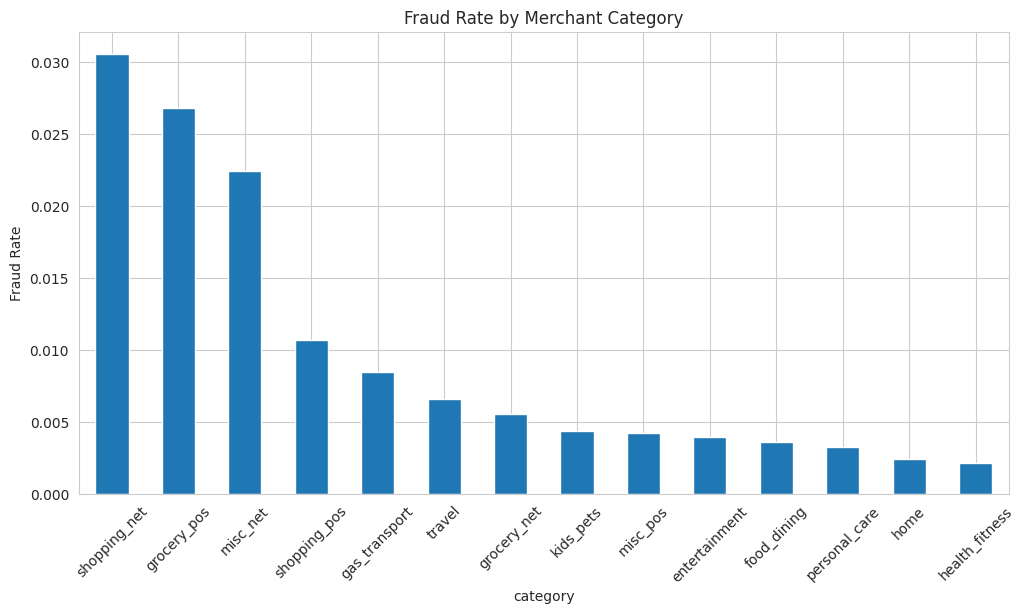

In [19]:
# faud by merchant category

category_fraud = (
    df.groupby("category")["transaction_is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

category_fraud.plot(kind="bar")

plt.title("Fraud Rate by Merchant Category")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=45)

plt.show()

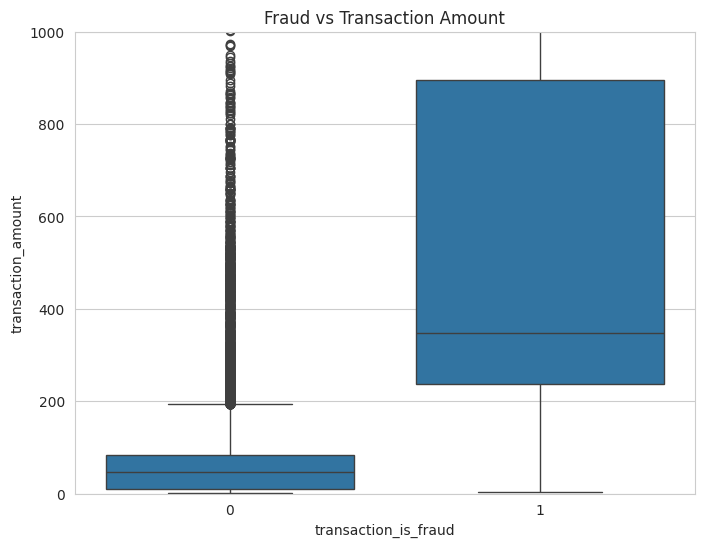

In [20]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="transaction_is_fraud",
    y="transaction_amount",
    data=df
)

plt.ylim(0, 1000)

plt.title("Fraud vs Transaction Amount")

plt.show()

This plot confirms that transaction_amount is a strong predictor for your model. If a transaction is for $800,
the probability of it being fraud is statistically much higher than a $50 transaction. However, because of those high-value legitimate outliers, your model will need other features (like location, time, or merchant type) to distinguish between a "big spender" and a "big thief."

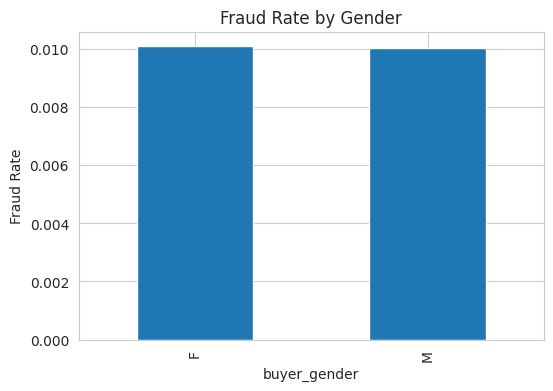

In [21]:
# FRAUD BY GENDER
gender_fraud = (
    df.groupby("buyer_gender")["transaction_is_fraud"]
    .mean()
)

plt.figure(figsize=(6,4))

gender_fraud.plot(kind="bar")

plt.title("Fraud Rate by Gender")
plt.ylabel("Fraud Rate")

plt.show()


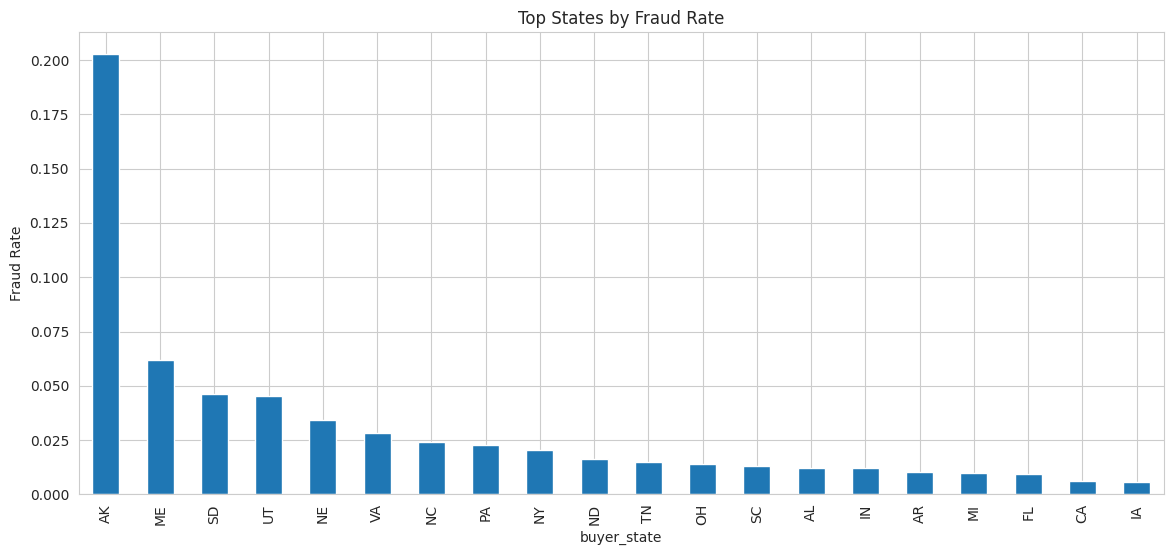

In [22]:
# FRAUD BY STATE
state_fraud = (
    df.groupby("buyer_state")["transaction_is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

state_fraud.head(20).plot(kind="bar")

plt.title("Top States by Fraud Rate")
plt.ylabel("Fraud Rate")

plt.show()

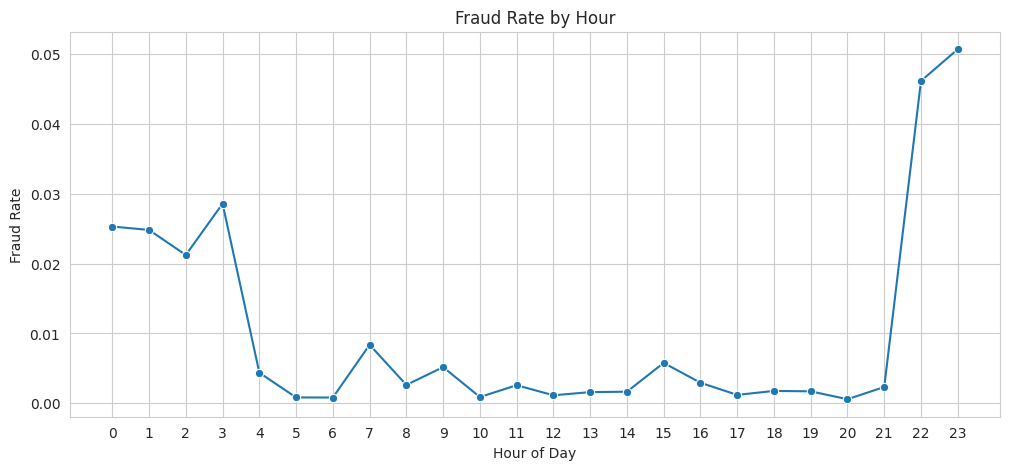

In [23]:
# FRAUD BY HOUR
hourly_fraud = (
    df.groupby("transaction_hour")["transaction_is_fraud"]
    .mean()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=hourly_fraud.index,
    y=hourly_fraud.values,
    marker="o"
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")

plt.xticks(range(0,24))

plt.show()

In [24]:
# Convert to datetime if not already
df["buyer_date_of_birth"] = pd.to_datetime(df["buyer_date_of_birth"])
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Correct age calculation
df["buyer_age"] = (
    (df["transaction_date"] - df["buyer_date_of_birth"])
    .dt.days // 365
)

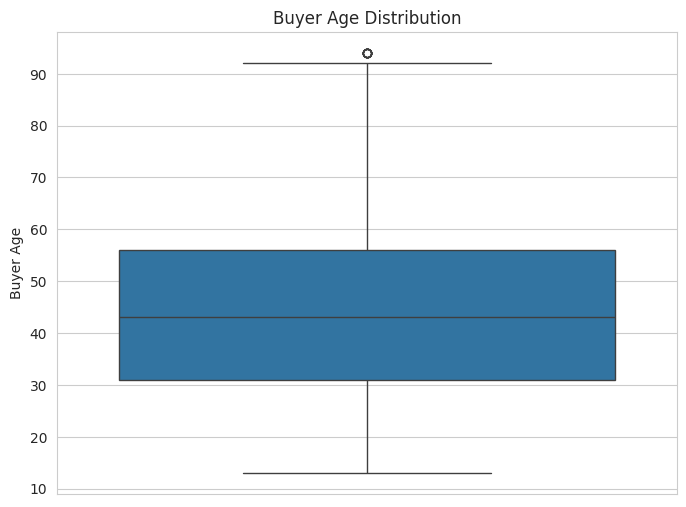

In [25]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df["buyer_age"])
plt.title("Buyer Age Distribution")
plt.ylabel("Buyer Age")
plt.show()

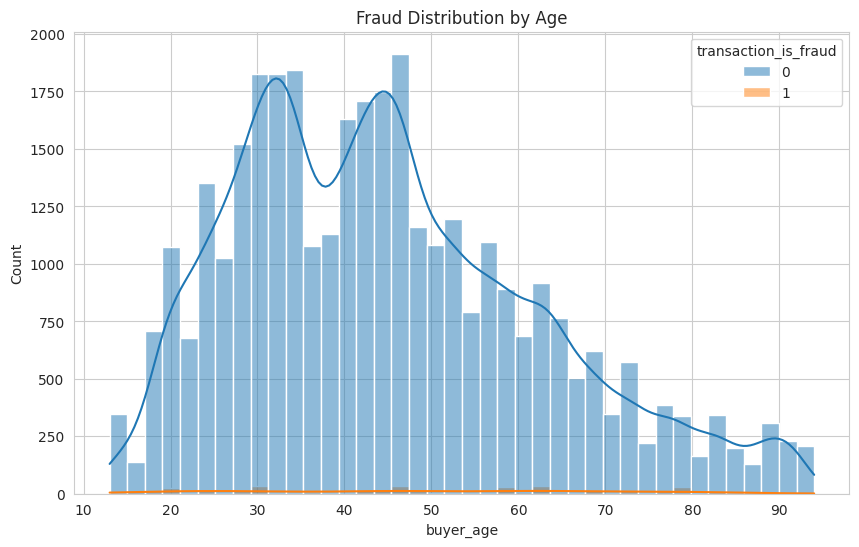

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="buyer_age",
    hue="transaction_is_fraud",
    bins=40,
    kde=True
)

plt.title("Fraud Distribution by Age")

plt.show()

In [27]:
print("Fraud Rate:")
print(df["transaction_is_fraud"].mean())

print("\nHighest Fraud Category:")
print(category_fraud.idxmax())

print("\nHighest Fraud State:")
print(state_fraud.idxmax())

print("\nAverage Fraud Amount:")
print(
    df[df["transaction_is_fraud"] == 1]["transaction_amount"].mean()
)

print("\nAverage not_Fraud Amount:")
print(
    df[df["transaction_is_fraud"] == 0]["transaction_amount"].mean()
)

Fraud Rate:
0.01007420091324201

Highest Fraud Category:
shopping_net

Highest Fraud State:
AK

Average Fraud Amount:
519.8384419263456

Average not_Fraud Amount:
67.56898261596562


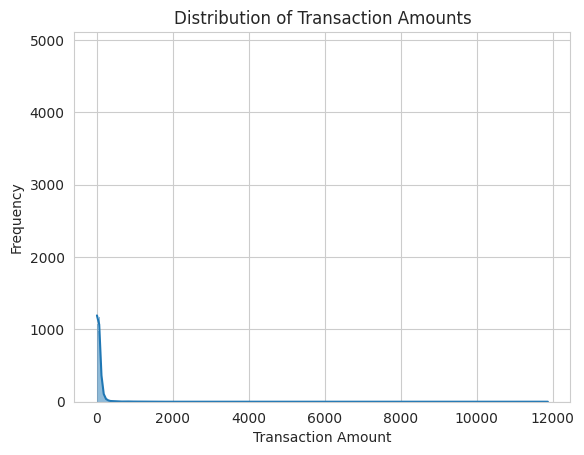

In [28]:
# Create the distribution plot
sns.histplot(df["transaction_amount"], kde=True)

# Add labels and title
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amounts")

# Display the plot
plt.show()

## Feature Engineering

In [29]:
drop_cols = [
    "transaction_date",
    "transaction_time",
    "buyer_date_of_birth",
    "merchant",
    "credit_card_number",
    "buyer_city",
    "buyer_state",
    "buyer_zip",
    "buyer_city_pop"
]

df.drop(drop_cols, axis=1, inplace=True)

In [30]:
df.head()

,category,transaction_amount,buyer_gender,buyer_lat,buyer_long,buyer_job,unix_time,merchant_lat,merchant_long,transaction_is_fraud,transaction_hour,buyer_age
0,misc_net,4.97,F,36.0788,-81.1781,"Psychologist, counselling",1325376018,36.011293,-82.048315,0,0,30
1,grocery_pos,107.23,F,48.8878,-118.2105,Special educational needs teacher,1325376044,49.159047,-118.186462,0,0,40
2,entertainment,220.11,M,42.1808,-112.2620,Nature conservation officer,1325376051,43.150704,-112.154481,0,0,56
3,gas_transport,45.00,M,46.2306,-112.1138,Patent attorney,1325376076,47.034331,-112.561071,0,0,52
4,misc_pos,41.96,M,38.4207,-79.4629,Dance movement psychotherapist,1325376186,38.674999,-78.632459,0,0,32


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35040 entries, 0 to 35039
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   category              35040 non-null  object 
 1   transaction_amount    35040 non-null  float64
 2   buyer_gender          35040 non-null  object 
 3   buyer_lat             35040 non-null  float64
 4   buyer_long            35040 non-null  float64
 5   buyer_job             35040 non-null  object 
 6   unix_time             35040 non-null  int64  
 7   merchant_lat          35040 non-null  float64
 8   merchant_long         35040 non-null  float64
 9   transaction_is_fraud  35040 non-null  int64  
 10  transaction_hour      35040 non-null  int32  
 11  buyer_age             35040 non-null  int64  
dtypes: float64(5), int32(1), int64(3), object(3)
memory usage: 3.3+ MB


In [32]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    # Radius of the Earth in km
    R = 6371.0

    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# Apply to your dataframe
df['distance_km'] = haversine_distance(
    df['buyer_lat'], df['buyer_long'],
    df['merchant_lat'], df['merchant_long']
)

In [33]:
# Log transform to handle the heavy right-skew
df['tansaction_amount'] = np.log1p(df['transaction_amount'])

In [34]:
# Create the Night Flag (10 PM to 3 AM)
df['is_night'] = df['transaction_hour'].apply(lambda x: 1 if x >= 22 or x <= 3 else 0)

## Preparing the data for Model Training

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

# 1. Clean up redundant columns
# Note: dropping 'buyer_job' and 'category' (unless you want to OHE category)
cols_to_drop = ['unix_time', 'buyer_lat', 'buyer_long', 'merchant_lat', 'merchant_long', 'transaction_amount', 'buyer_job']
df_final = df.drop(columns=cols_to_drop)

# 2. Encode categorical columns
le = LabelEncoder()
df_final['buyer_gender'] = le.fit_transform(df_final['buyer_gender'])
df_final['category'] = le.fit_transform(df_final['category'])

# 3. Features and Target
X = df_final.drop('transaction_is_fraud', axis=1)
y = df_final['transaction_is_fraud']

# 4. Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Scale the data

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Selection

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd

# Calculate the scale factor for XGBoost
# (Total Negative Cases / Total Positive Cases)
scale_pos_weight_value = len(y_train[y_train==0]) / len(y_train[y_train==1])

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=10),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=100, n_jobs=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight_value, eval_metric='logloss')
}

performance = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    performance.append({
        "Model": name,
        "F1 Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

results_df = pd.DataFrame(performance).sort_values(by="F1 Score", ascending=False)
print(results_df)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
                 Model  F1 Score  Precision    Recall
3              XGBoost  0.821192   0.775000  0.873239
2        Random Forest  0.796748   0.942308  0.690141
1        Decision Tree  0.447653   0.300971  0.873239
0  Logistic Regression  0.095166   0.050279  0.887324


## Hyperparameter Tuning

In [43]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

# Initialize the model with your existing scale_pos_weight
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Use RandomizedSearch focusing on F1-score
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=10, # Number of parameter combinations to try
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting Hyperparameter Tuning...")
random_search.fit(X_train_scaled, y_train)

# Best parameters and score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best F1 Score from CV: {random_search.best_score_}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best F1 Score from CV: 0.8137270316152785
